In [2]:
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.datasets import mnist

In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data() 

In [4]:
print("X Train",x_train.shape)
print("X Test",x_test.shape)
print("Y Train",y_train.shape)
print("Y Test",y_test.shape)

X Train (60000, 28, 28)
X Test (10000, 28, 28)
Y Train (60000,)
Y Test (10000,)


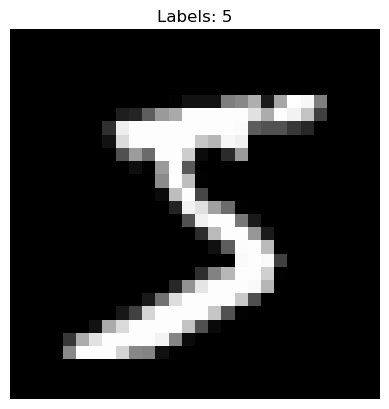

In [5]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0], cmap='gray')
plt.title(f"Labels: {y_train[0]}")
plt.axis("Off")
plt.show()

In [6]:
print(x_train[0].shape)

(28, 28)


In [7]:
print(x_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

In [8]:
x_train = x_train/255.0
x_test = x_test/255.0

In [9]:
print(x_train.min())
print(x_train.max())

0.0
1.0


In [10]:
x_train = x_train.reshape(-1, 28*28)

x_test = x_test.reshape(-1, 28*28)

In [11]:
print(x_train.shape)
print(x_test.shape)

(60000, 784)
(10000, 784)


In [12]:
model = keras.Sequential([

    keras.Input(shape=(784,)),

    keras.layers.Dense(128, activation='relu'),

    keras.layers.Dense(64, activation='relu'),

    keras.layers.Dense(10, activation='softmax')

])

In [13]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy'] 
)

In [14]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9241 - loss: 0.2548 - val_accuracy: 0.9645 - val_loss: 0.1219
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9673 - loss: 0.1074 - val_accuracy: 0.9712 - val_loss: 0.1004
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9770 - loss: 0.0730 - val_accuracy: 0.9752 - val_loss: 0.0807
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9816 - loss: 0.0550 - val_accuracy: 0.9775 - val_loss: 0.0873
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9861 - loss: 0.0427 - val_accuracy: 0.9713 - val_loss: 0.1002
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9883 - loss: 0.0353 - val_accuracy: 0.9733 - val_loss: 0.1025
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9908 - loss: 0.0281 - val_accuracy: 0.9762 - val_loss: 0.0846
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9920 - loss: 0.0246 - 

In [15]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9805 - loss: 0.0826


In [16]:
print("Test Accuracy",test_accuracy)

Test Accuracy 0.9804999828338623


In [17]:
predictions = model.predict(x_test)
print(predictions[:5])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[[1.4538684e-14 9.3129127e-10 1.1224978e-08 5.1960383e-06 1.6254016e-13
  3.7486910e-12 5.4533400e-18 9.9999404e-01 1.4788756e-09 7.3157628e-07]
 [1.1207766e-14 1.1538364e-09 1.0000000e+00 7.7185599e-13 2.0766642e-22
  4.0711225e-16 4.8053320e-13 8.6145236e-16 8.0622066e-14 1.7657501e-25]
 [4.4639639e-09 9.9994612e-01 1.7443951e-07 1.8627257e-12 2.4149911e-05
  9.6999179e-07 9.8319024e-06 1.8555038e-05 2.0474799e-07 6.0490124e-09]
 [9.9999976e-01 3.8197179e-09 4.9269978e-08 1.4450964e-10 1.2463063e-11
  4.6892035e-12 1.2047673e-08 3.1435203e-08 2.7014555e-09 7.9221579e-08]
 [5.4800292e-10 5.0042033e-11 2.1169179e-11 3.9031205e-13 9.9995899e-01
  8.3118609e-13 1.6997760e-10 2.2906230e-08 2.4906435e-12 4.0964722e-05]]


In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 328,160 (1.25 MB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 218,774 (854.59 KB)

In [19]:
import numpy as np

predicted_labels = np.argmax(predictions, axis=1)

print("Predicted: ",predicted_labels[:5])
print("Actual: ",y_test[:5])

Predicted:  [7 2 1 0 4]
Actual:  [7 2 1 0 4]


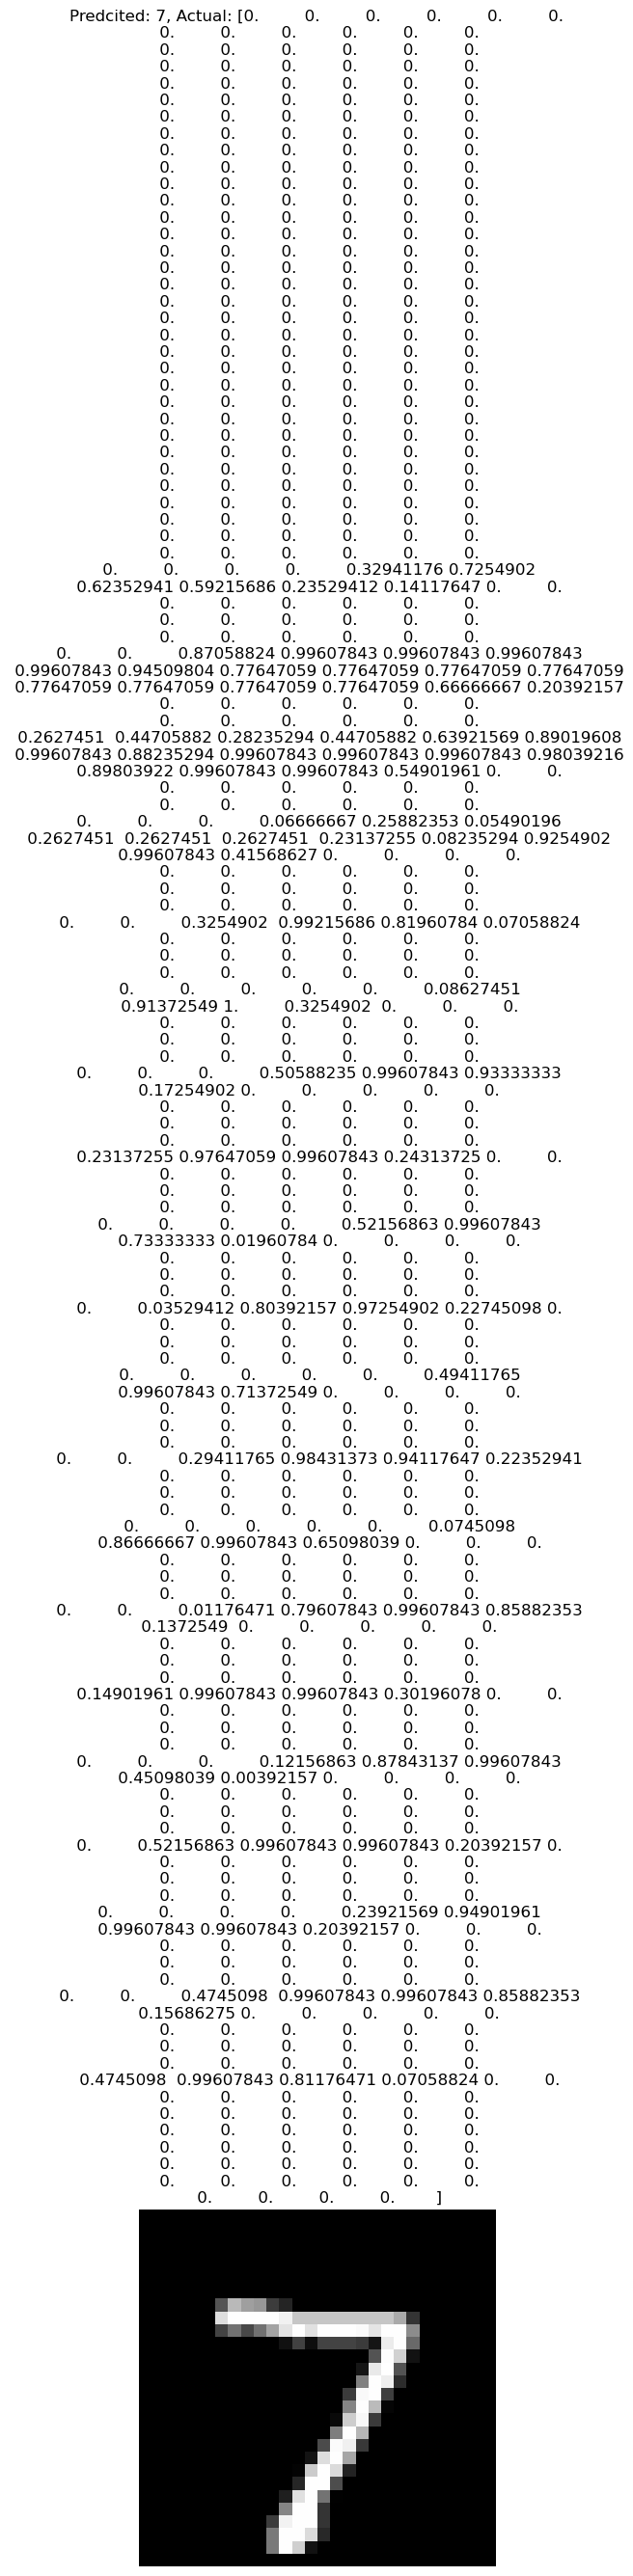

In [20]:
import matplotlib.pyplot as plt

plt.imshow(x_test[0].reshape(28,28), cmap='gray')
plt.title(f"Predcited: {predicted_labels[0]}, "
         f"Actual: {x_test[0]}")

plt.axis("off")
plt.show()

In [21]:
print("Best Training Accuracy: ",max(history.history['accuracy']))
print("Best Validation Accuracy: ",max(history.history['val_accuracy']))    

Best Training Accuracy:  0.9934999942779541
Best Validation Accuracy:  0.9800000190734863


In [22]:
print("Best Validation Accuracy: ",max(history.history["val_accuracy"]))
print("Best Validation Loss: ",max(history.history["val_loss"]))

Best Validation Accuracy:  0.9800000190734863
Best Validation Loss:  0.12190580368041992


In [23]:
print("Epochs Trained: ", max(history.history['loss']))

Epochs Trained:  0.254839152097702
